# Outlier Detection

In [1]:
import os, sys
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import numpy as np
import pandas as pd
from typing import List
from datetime import datetime, timedelta, timezone

from typing import List
from collections import Counter

import matplotlib.pyplot as plt

import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout

data_path = "../kgdata/edges_v3.tsv"
df = pd.read_csv(data_path, sep='\t')

print(df["label"].unique())

['type' 'EventId' 'DescriptionText' 'EventType' 'StartTime' 'EndTime'
 'StartDistanceFromPort_km' 'StartDistanceFromShore_km'
 'EndDistanceFromPort_km' 'EndDistanceFromShore_km' 'Location'
 'EventGeometry' 'HasParticipant' 'ValidatedBy' 'ExplainedBy'
 'HasProvenance' 'BehaviorType' 'UncertaintyNote' 'AvgSpeed_knots'
 'PatternGeometry' 'UnexplainedByWeatherOrPort' 'ObservationId' 'MMSI'
 'Lat' 'Lon' 'Speed' 'Course' 'Timestamp' 'DistanceFromPortKM'
 'DistanceFromShoreKM' 'Source' 'SSVID' 'VesselName' 'CallSign' 'Flag'
 'VesselTypeId' 'GroupType' 'HasMember' 'AsWKT' 'CentroidLat'
 'CentroidLon' 'CRS' 'PortName' 'BerthGeometry' 'TypeCode' 'TypeName'
 'subClassOf' 'FishingEffortScore' 'GearType' 'ZoneCode' 'ZoneName'
 'ZoneType' 'ZoneGeometry' 'SourceID' 'SourceName' 'SourceType'
 'SourceURL' 'MemberVessel' 'MembershipRole' 'MemberOf' 'PatternTypeID'
 'PatternTypeName' 'domain' 'range' ' type']


In [2]:
def vessel2event(vessel: str):
    return df[(df["label"] == "HasParticipant") & (df["node2"] == vessel)].node1.to_list()

def event2info(event: str, labels: List):
    tdf = df[df["node1"] == event]
    return [tdf[tdf["label"] == label]["node2"].values[0] for label in labels]

In [3]:
each_events = vessel2event("VesselIdentity_16")
events = []
for i in range(0, 17):
    each_events = vessel2event(f"VesselIdentity_{i}")
    events += each_events

print(len(events))

1698


In [4]:
df[df["node1"] == events[0]]["label"].unique()

array(['type', 'EventId', 'DescriptionText', 'EventType', 'StartTime',
       'EndTime', 'StartDistanceFromPort_km', 'StartDistanceFromShore_km',
       'EndDistanceFromPort_km', 'EndDistanceFromShore_km', 'Location',
       'EventGeometry', 'HasParticipant', 'ValidatedBy', 'ExplainedBy',
       'HasProvenance', 'PortName', 'BerthGeometry'], dtype=object)

In [5]:
labels = ["EventType",
          "StartTime",
          "EndTime",
          "StartDistanceFromPort_km",
          "StartDistanceFromShore_km",
          "EndDistanceFromPort_km",
          "EndDistanceFromShore_km",
          "Location"]

info = event2info(events[0], labels)
print(info)

['port_visit', '^2024-03-20T14:56:51+00:00', '^2024-03-20T14:56:51+00:00', '0.0', '0.0', '0.0', '0.0', 'Zone_207']


In [6]:
print(df[df["label"] == "Location"]["node2"].unique())
print(df[df["label"] == "EventGeometry"]["node2"].unique())

Counter(df[df["label"] == "Location"]["node2"])

['Zone_204' 'Zone_196' 'Zone_222' 'Zone_207']
['Geometry_561' 'Geometry_562' 'Geometry_563' ... 'Geometry_2256'
 'Geometry_2257' 'Geometry_2258']


Counter({'Zone_204': 1072, 'Zone_207': 408, 'Zone_196': 179, 'Zone_222': 39})

In [7]:
from sklearn import preprocessing

event_categories = df[df["label"] == "EventType"]["node2"].unique()
event_encoder = preprocessing.OneHotEncoder(
    categories=[event_categories],
    sparse_output=False,
    handle_unknown="ignore")

event_encoder.fit(event_categories.reshape(-1, 1))

zone_categories = df[df["label"] == "Location"]["node2"].unique()
zone_encoder = preprocessing.OneHotEncoder(
    categories=[zone_categories],
    sparse_output=False,
    handle_unknown="ignore")

zone_encoder.fit(zone_categories.reshape(-1, 1))

,categories,[array(['Zone_... dtype=object)]
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [8]:
def time_extract(start: str, end: str) -> List:
    s_dt = datetime.fromisoformat(start)
    e_dt = datetime.fromisoformat(end)

    s_ts = int(s_dt.timestamp())
    e_ts = int(e_dt.timestamp())
    return s_ts, e_ts

s_ts, e_ts = time_extract(info[1][1:], info[2][1:])
print(s_ts, e_ts)

1710946611 1710946611


In [9]:
vessel_event_info_s = [event2info(event, labels) for event in events]

feats = []
for event_info in vessel_event_info_s:
    event_f = event_encoder.transform(np.array([[event_info[0]]])).astype(float)
    time_f = np.array(time_extract(event_info[1][1:], event_info[2][1:])).reshape(1, -1)
    raw_f = np.array(event_info[3:7]).reshape(1, -1)
    zone_f = zone_encoder.transform(np.array([[event_info[7]]])).astype(float)
    feat = np.hstack([event_f, time_f, raw_f, zone_f])
    feats.append(feat)

In [42]:
feats = np.vstack(feats)
print(feats[0:3])
print(type(feats))

[['0.0' '1.0' '0.0' '1710946611' '1710946611' '0.0' '0.0' '0.0' '0.0'
  '0.0' '0.0' '0.0' '1.0']
 ['0.0' '1.0' '0.0' '1711089812' '1711089812' '0.0' '7.0' '0.0' '5.0'
  '0.0' '0.0' '0.0' '1.0']
 ['0.0' '1.0' '0.0' '1735274677' '1735274677' '0.0' '9.0' '0.0' '9.0'
  '0.0' '0.0' '0.0' '1.0']]
<class 'numpy.ndarray'>


## K-Means Clustering

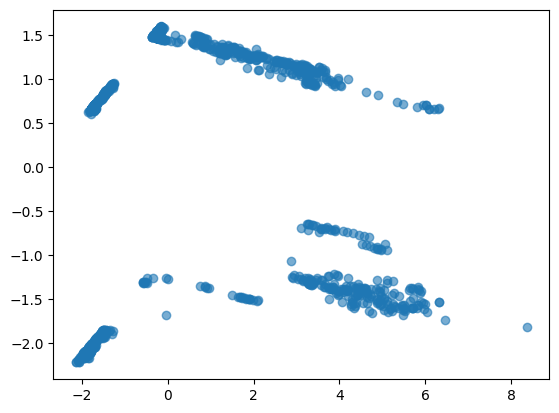

In [24]:
from sklearn import cluster
from sklearn import preprocessing
from sklearn import decomposition

X = feats[:, 3:].astype(float)
X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10)
scaler = preprocessing.StandardScaler()
X = scaler.fit_transform(X)
y = [x[0] for x in vessel_event_info_s]

pca = decomposition.PCA(n_components=2)
XX = pca.fit_transform(X)

plt.scatter(XX[:, 0], XX[:, 1], alpha=0.6)
plt.show()

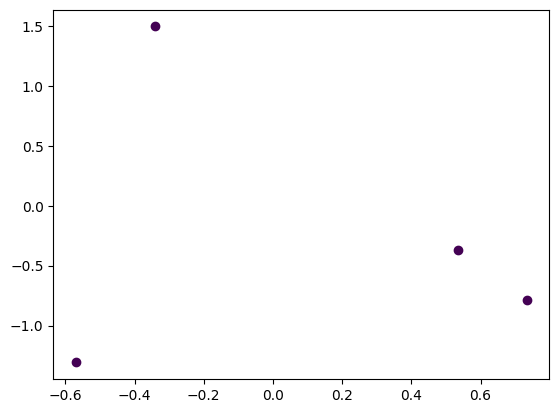

In [41]:
X_a = [[1710946611, 1710946611, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]]
X_b = [[1710946611, 1710946611, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]]
X_c = [[1710946611, 1710946611, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]]
X_d = [[1710946611, 1710946611, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]]

XX_a = pca.transform(scaler.transform(X_a))[0]
XX_b = pca.transform(scaler.transform(X_b))[0]
XX_c = pca.transform(scaler.transform(X_c))[0]
XX_d = pca.transform(scaler.transform(X_d))[0]

plt.scatter(XX_a[0], XX_a[1], c=1)
plt.scatter(XX_b[0], XX_b[1], c=2)
plt.scatter(XX_c[0], XX_c[1], c=3)
plt.scatter(XX_d[0], XX_d[1], c=4)

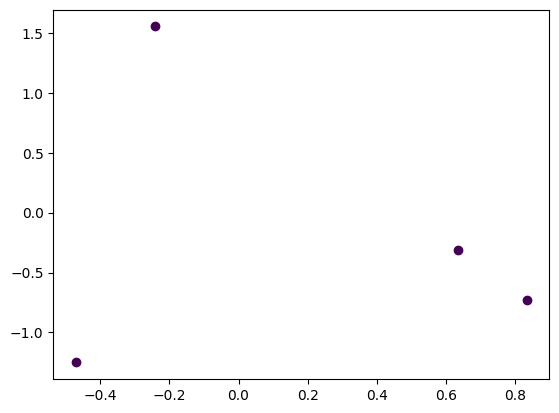

In [43]:
X_a = [[1735274677, 1735274677, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]]
X_b = [[1735274677, 1735274677, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]]
X_c = [[1735274677, 1735274677, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0]]
X_d = [[1735274677, 1735274677, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]]

XX_a = pca.transform(scaler.transform(X_a))[0]
XX_b = pca.transform(scaler.transform(X_b))[0]
XX_c = pca.transform(scaler.transform(X_c))[0]
XX_d = pca.transform(scaler.transform(X_d))[0]

plt.scatter(XX_a[0], XX_a[1], c=1)
plt.scatter(XX_b[0], XX_b[1], c=2)
plt.scatter(XX_c[0], XX_c[1], c=3)
plt.scatter(XX_d[0], XX_d[1], c=4)

In [26]:
kmeans = cluster.KMeans(n_clusters=3,
                        init="k-means++",
                        n_init="auto")
kmeans.fit(X)
y_pred = kmeans.labels_

In [27]:
def plot(X, y, y_pred):
    cmap = {yy: i for i, yy in enumerate(y)}
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for label in event_categories:
        mask = [yy == label for yy in y]
        axes[0].scatter(X[mask, 0], X[mask, 1], label=label, alpha=0.6)
    axes[0].set_title("label")
    axes[0].legend(title="class")
    axes[1].scatter(X[:, 0], X[:, 1], c=y_pred, alpha=0.6)
    axes[1].set_title("predict")
    plt.show()

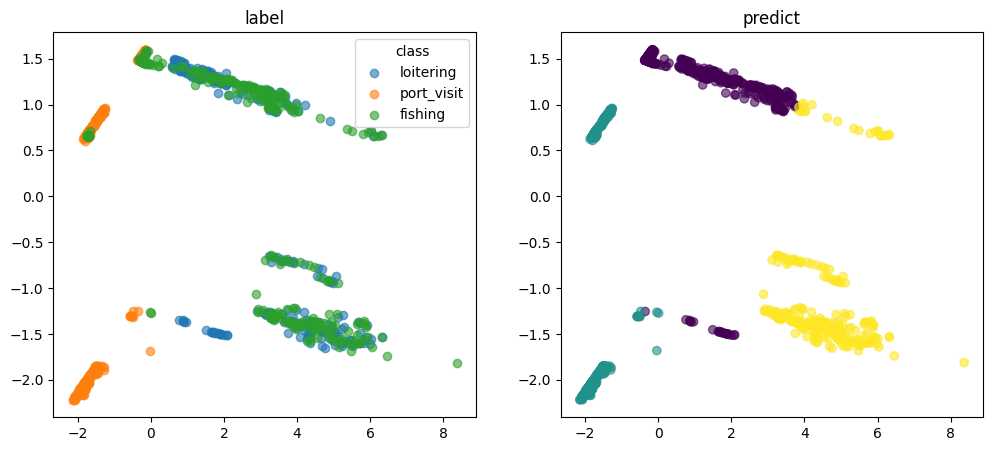

In [28]:
plot(XX, y, y_pred)

## GuassianMixture


In [29]:
from sklearn import mixture

gm = mixture.GaussianMixture(n_components=3,
                             covariance_type="full",
                             random_state=4444)
gm.fit(X)
y_pred = gm.predict(X)

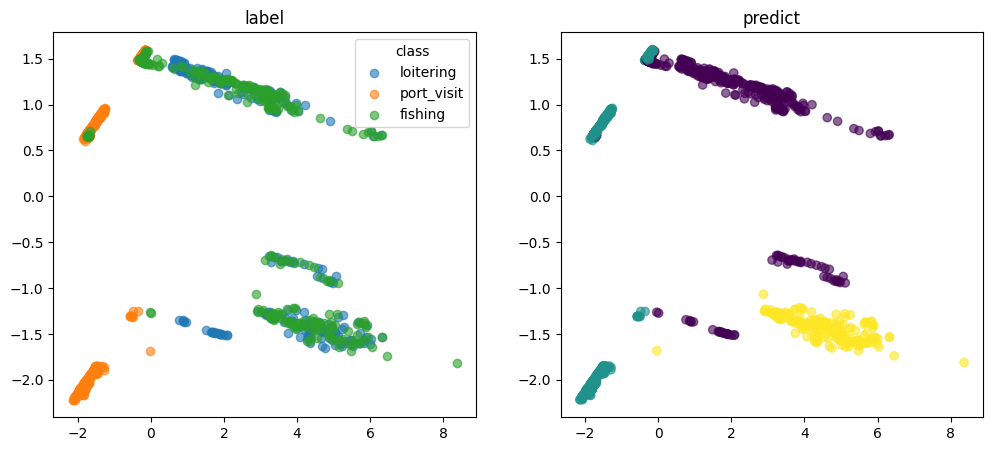

In [30]:
plot(XX, y, y_pred)

## Kernel PCA

In [31]:
kpca = decomposition.KernelPCA(
    n_components=10,
    kernel="rbf",
    gamma=0.5
)

XXX = kpca.fit_transform(X)
kmeans = cluster.KMeans(n_clusters=3,
                        init="k-means++",
                        n_init="auto")
kmeans.fit(XXX)
y_pred = kmeans.labels_

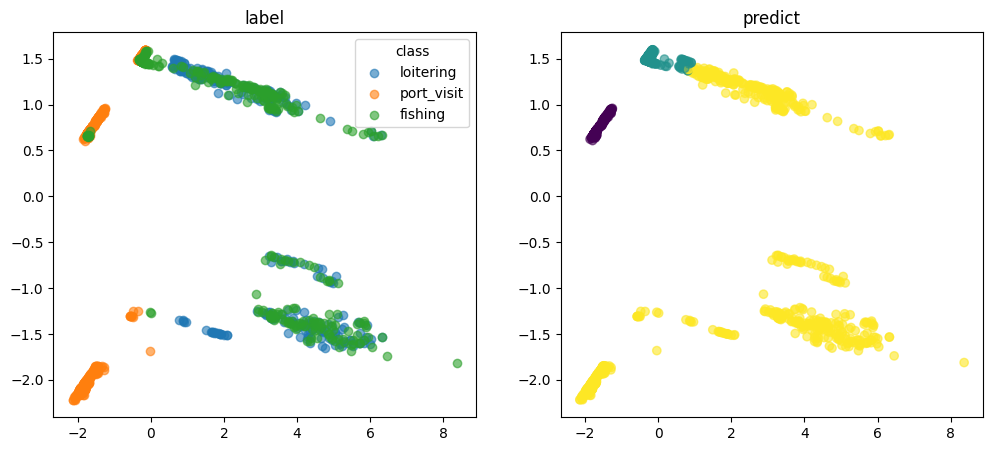

In [32]:
plot(XX, y, y_pred)

In [33]:
gm = mixture.GaussianMixture(n_components=3,
                             covariance_type="full",
                             random_state=4444)

y_pred = gm.fit_predict(XXX)

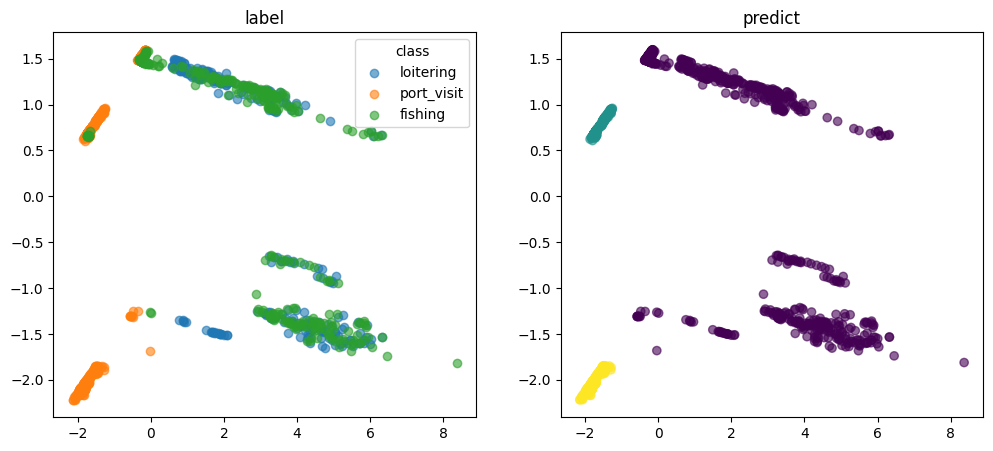

In [34]:
plot(XX, y, y_pred)